In [ ]:
# Environment setup
%load_ext autoreload
%autoreload 2

import os
os.chdir("..")


In [ ]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

# ClauseTree related imports
from aether.clause.tree.generator import ClauseGenerator
from aether.clause.nodes.nodes import (
    SMA, ADD, DIV, SUB, SHIFT, DIFF, PctChange, 
    STD, CORR, DATA, ABS, ShiftSign
)

# ClauseGraph related imports
from aether.clause.graph import ClauseGraph, EdgeCalculator, SubgraphExtractor


In [5]:
# 1. Prepare Basic Nodes and ClauseTree Generator
nodes = [
    # Basic operations
    ADD(), DIV(), SUB(), ABS(), ShiftSign(),
    
    # Time series analysis
    SMA(period=5), SMA(period=10), SMA(period=20),
    SHIFT(period=1), SHIFT(period=5),
    DIFF(period=1), DIFF(period=5),
    PctChange(period=1), PctChange(period=5),
    STD(period=10), STD(period=20),
    CORR(period=10), CORR(period=20),
    
    # Data nodes
    DATA("OPEN", "BTCUSDT"),
    DATA("HIGH", "BTCUSDT"), 
    DATA("LOW", "BTCUSDT"),
    DATA("CLOSE", "BTCUSDT"),
    DATA("VOLUME", "BTCUSDT"),
]

# ClauseTree generator
generator = ClauseGenerator(nodes)

print(f"Total {len(nodes)} node types prepared.")


Loading dataframes ...: 100%|██████████| 80/80 [00:00<00:00, 107.92it/s]

총 23개의 노드 타입이 준비되었습니다.


In [7]:
# 2. Generate Multiple ClauseTrees
trees = []
n_trees = 8

print(f"Generating {n_trees} ClauseTrees...")

for i in range(n_trees):
    # Generate trees with various depths (2~4)
    max_depth = np.random.randint(2, 5)
    tree = generator.generate(max_depth=max_depth)
    tree.name = f"Tree_{i}"

    if tree.iscompleted:
        trees.append(tree)
        print(f"Tree {i}: depth={tree.depth}, nodes={len(tree.nodes)}, completed={tree.iscompleted}")

print(f"\nTotal {len(trees)} ClauseTrees generated.")


8개의 ClauseTree를 생성합니다...
Tree 0: 깊이=5, 노드수=7, 완성=True
Tree 1: 깊이=4, 노드수=5, 완성=True
Tree 2: 깊이=2, 노드수=3, 완성=True
Tree 3: 깊이=7, 노드수=13, 완성=True
Tree 4: 깊이=8, 노드수=16, 완성=True
Tree 5: 깊이=8, 노드수=20, 완성=True

총 6개의 ClauseTree가 생성되었습니다.


In [8]:
# 3. Create ClauseGraph and Add Trees
clause_graph = ClauseGraph(name="DemoGraph")

# Add ClauseTrees as graph nodes
node_ids = clause_graph.add_clause_trees(trees)

print(f"ClauseGraph creation complete:")
print(f"- Nodes: {clause_graph.num_nodes}")
print(f"- Edges: {clause_graph.num_edges}")
print(f"- Node IDs: {node_ids}")


2025-09-22 22:26:17 - aether.clause.graph.base - INFO - Added ClauseTree as node 0
2025-09-22 22:26:17 - aether.clause.graph.base - INFO - Added ClauseTree as node 1
2025-09-22 22:26:17 - aether.clause.graph.base - INFO - Added ClauseTree as node 2
2025-09-22 22:26:17 - aether.clause.graph.base - INFO - Added ClauseTree as node 3
2025-09-22 22:26:17 - aether.clause.graph.base - INFO - Added ClauseTree as node 4
2025-09-22 22:26:17 - aether.clause.graph.base - INFO - Added ClauseTree as node 5
ClauseGraph 생성 완료:
- 노드 수: 6
- 간선 수: 0
- 노드 ID들: [0, 1, 2, 3, 4, 5]


In [9]:
# 4. Graph Learning (Edge Weight Calculation for All Node Pairs)
print("="*50)
print("Graph Learning Start: Computing edge weights for all node pairs")
print("="*50)

# Set edge weight calculation function (shell function)
edge_calculator = EdgeCalculator.get_calculator('simple')
clause_graph.set_edge_calculator(edge_calculator)

total_pairs = clause_graph.num_nodes * (clause_graph.num_nodes - 1) // 2
print(f"Node pairs to process: {total_pairs}")

# Compute edge weights for all node pairs (add edges with threshold >= 0.4)
clause_graph.compute_all_edges(threshold=0.4)

print(f"\nGraph Learning Complete:")
print(f"- Nodes: {clause_graph.num_nodes}")
print(f"- Edges: {clause_graph.num_edges}")
print(f"- Graph density: {clause_graph.num_edges / total_pairs:.3f}")
print(f"- Edges above threshold 0.4: {clause_graph.num_edges / total_pairs:.1%}")


그래프 학습 시작: 모든 노드 쌍에 대해 간선 가중치 계산
2025-09-22 22:26:22 - aether.clause.graph.base - INFO - Edge calculator set
처리할 노드 쌍 수: 15
2025-09-22 22:26:22 - aether.clause.graph.base - INFO - Added 7 edges with threshold 0.4

그래프 학습 완료:
- 노드 수: 6
- 간선 수: 7
- 그래프 밀도: 0.467
- 임계값 0.4 이상인 간선 비율: 46.7%


In [ ]:
# 4.5. Graph Visualization
plt.figure(figsize=(15, 10))

# Full graph visualization
plt.subplot(2, 2, 1)
if clause_graph.num_edges > 0:
    # Layout calculation
    pos = nx.spring_layout(clause_graph.graph, k=2, iterations=50)
    
    # Draw nodes
    nx.draw_networkx_nodes(clause_graph.graph, pos, 
                          node_color='lightblue', 
                          node_size=1000,
                          alpha=0.8)
    
    # Draw edges (thickness based on weight)
    edge_weights = [clause_graph.graph[u][v]['weight'] for u, v in clause_graph.graph.edges()]
    nx.draw_networkx_edges(clause_graph.graph, pos, 
                          width=[w*4 for w in edge_weights],
                          alpha=0.6,
                          edge_color='gray')
    
    # Node labels
    node_labels = {node_id: f"T{node_id}" for node_id in clause_graph.clause_trees.keys()}
    nx.draw_networkx_labels(clause_graph.graph, pos, node_labels, font_size=12, font_weight='bold')
    
    plt.title(f"Full ClauseGraph\n(Nodes: {clause_graph.num_nodes}, Edges: {clause_graph.num_edges})")
else:
    plt.text(0.5, 0.5, 'No edges to display', ha='center', va='center', transform=plt.gca().transAxes)
    plt.title("Full ClauseGraph (No edges)")

plt.axis('off')

# Edge weight distribution
plt.subplot(2, 2, 2)
if clause_graph.num_edges > 0:
    edge_weights = [clause_graph.graph[u][v]['weight'] for u, v in clause_graph.graph.edges()]
    plt.hist(edge_weights, bins=10, alpha=0.7, edgecolor='black', color='skyblue')
    plt.xlabel('Edge Weight')
    plt.ylabel('Frequency')
    plt.title('Edge Weight Distribution')
    plt.grid(True, alpha=0.3)
    
    # Add statistics
    mean_weight = np.mean(edge_weights)
    plt.axvline(mean_weight, color='red', linestyle='--', label=f'Mean: {mean_weight:.3f}')
    plt.legend()
else:
    plt.text(0.5, 0.5, 'No edges to analyze', ha='center', va='center', transform=plt.gca().transAxes)
    plt.title('Edge Weight Distribution (No data)')

# Node characteristics (tree size vs depth)
plt.subplot(2, 2, 3)
node_sizes = [len(clause_graph.get_clause_tree(nid).nodes) for nid in clause_graph.clause_trees.keys()]
node_depths = [clause_graph.get_clause_tree(nid).depth for nid in clause_graph.clause_trees.keys()]

plt.scatter(node_sizes, node_depths, s=100, alpha=0.7, c='lightcoral')
for i, nid in enumerate(clause_graph.clause_trees.keys()):
    plt.annotate(f'T{nid}', (node_sizes[i], node_depths[i]), xytext=(5, 5), 
                textcoords='offset points', fontsize=10)

plt.xlabel('Tree Node Count')
plt.ylabel('Tree Depth')
plt.title('ClauseTree Characteristics')
plt.grid(True, alpha=0.3)

# Connectivity information
plt.subplot(2, 2, 4)
# Calculate degree for each node
degrees = dict(clause_graph.graph.degree())
node_ids = list(degrees.keys())
degree_values = list(degrees.values())

bars = plt.bar([f'T{nid}' for nid in node_ids], degree_values, 
               color='lightgreen', alpha=0.7, edgecolor='black')
plt.xlabel('Node')
plt.ylabel('Degree')
plt.title('Node Connectivity')
plt.xticks(rotation=45)

# Show values on bars
for bar, degree in zip(bars, degree_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, 
             str(degree), ha='center', va='bottom')

plt.tight_layout()
plt.show()

print(f"📊 Visualization completed!")
print(f"- Max connections: {max(degree_values) if degree_values else 0}")
print(f"- Avg connections: {np.mean(degree_values):.1f}" if degree_values else "- Avg connections: 0")
print(f"- Connected components: {nx.number_connected_components(clause_graph.graph)}")


In [10]:
# 5. Subgraph Extraction (Random Walk)
extractor = SubgraphExtractor(clause_graph)

# Random walk subgraph extraction
subgraph_size = 4

print("Random Walk Subgraph Extraction:")

# Basic extraction
result1 = extractor.extract_subgraph(size=subgraph_size)
print(f"Extraction 1: nodes {result1['nodes']}, {len(result1['edges'])} edges")

# High restart probability
result2 = extractor.extract_subgraph(size=subgraph_size, restart_probability=0.3)
print(f"Extraction 2 (high restart): nodes {result2['nodes']}, {len(result2['edges'])} edges")

# Long walk length
result3 = extractor.extract_subgraph(size=subgraph_size, walk_length_factor=3.0)
print(f"Extraction 3 (long walk): nodes {result3['nodes']}, {len(result3['edges'])} edges")

# Extraction statistics
stats = extractor.extraction_stats
print(f"\nExtraction stats: {stats['extractions']} attempts completed")


랜덤 워크 서브그래프 추출:
추출 1: 노드 [np.int64(0), 1, np.int64(2), 4], 간선 3개
추출 2 (높은 재시작): 노드 [1, np.int64(3), 4, np.int64(5)], 간선 3개
추출 3 (긴 워크): 노드 [np.int64(0), np.int64(1), np.int64(3), 4], 간선 3개

추출 통계: 3회 시도, 평균 크기 4.0


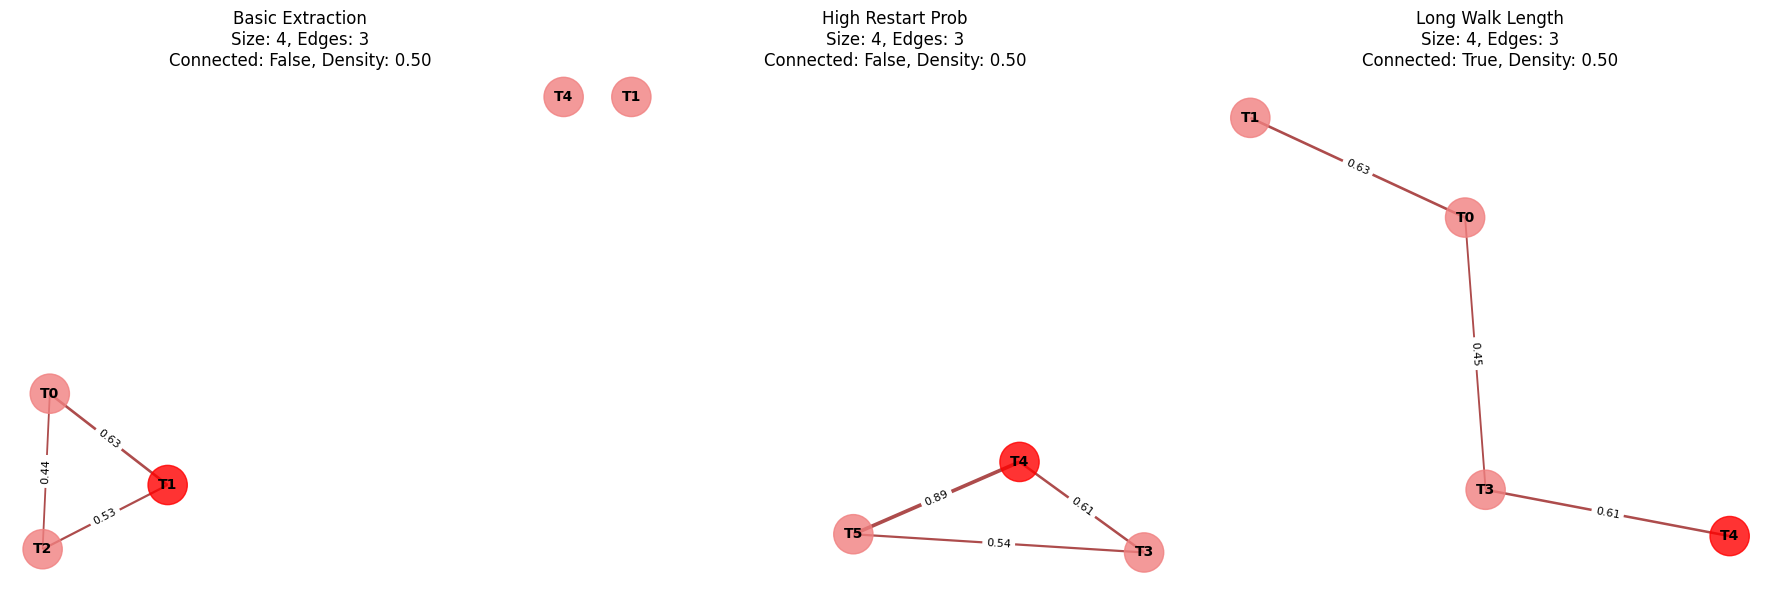

🔍 Subgraph Comparison:

1. Basic Extraction:
   - Nodes: [np.int64(0), 1, np.int64(2), 4]
   - Start node: T1 (red)
   - Edges: 3
   - Connected: No

2. High Restart Prob:
   - Nodes: [1, np.int64(3), 4, np.int64(5)]
   - Start node: T4 (red)
   - Edges: 3
   - Connected: No

3. Long Walk Length:
   - Nodes: [np.int64(0), np.int64(1), np.int64(3), 4]
   - Start node: T4 (red)
   - Edges: 3
   - Connected: Yes

📊 Subgraph Overlap Analysis:
Subgraph 1 vs 2: 2 overlapping nodes (33.3%)
  Common nodes: [1, 4]
Subgraph 1 vs 3: 3 overlapping nodes (60.0%)
  Common nodes: [np.int64(0), np.int64(1), 4]
Subgraph 2 vs 3: 3 overlapping nodes (60.0%)
  Common nodes: [np.int64(1), np.int64(3), 4]


In [13]:
# 5.5. Subgraph Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Visualize extracted subgraphs
results = [result1, result2, result3]
titles = ['Basic Extraction', 'High Restart Prob', 'Long Walk Length']

for i, (result, title) in enumerate(zip(results, titles)):
    ax = axes[i]
    subgraph = result['subgraph']
    
    if subgraph.number_of_edges() > 0:
        # Subgraph layout
        pos = nx.spring_layout(subgraph, k=1, iterations=50)
        
        # Draw nodes (start node in different color)
        node_colors = []
        for node_id in subgraph.nodes():
            if node_id == result['start_node']:
                node_colors.append('red')  # Start node
            else:
                node_colors.append('lightcoral')
        
        nx.draw_networkx_nodes(subgraph, pos, ax=ax,
                              node_color=node_colors,
                              node_size=800,
                              alpha=0.8)
        
        # Draw edges
        edge_weights = [subgraph[u][v]['weight'] for u, v in subgraph.edges()]
        nx.draw_networkx_edges(subgraph, pos, ax=ax,
                              width=[w*3 for w in edge_weights],
                              alpha=0.7,
                              edge_color='darkred')
        
        # Node labels
        node_labels = {node_id: f"T{node_id}" for node_id in subgraph.nodes()}
        nx.draw_networkx_labels(subgraph, pos, node_labels, ax=ax, font_size=10, font_weight='bold')
        
        # Edge weight labels (optional)
        edge_labels = {}
        for (u, v) in subgraph.edges():
            weight = subgraph[u][v]['weight']
            edge_labels[(u, v)] = f"{weight:.2f}"
        nx.draw_networkx_edge_labels(subgraph, pos, edge_labels, ax=ax, font_size=8)
        
    else:
        # Show only nodes if no edges
        pos = {node_id: (i*0.3, 0) for i, node_id in enumerate(subgraph.nodes())}
        
        node_colors = []
        for node_id in subgraph.nodes():
            if node_id == result['start_node']:
                node_colors.append('red')
            else:
                node_colors.append('lightcoral')
                
        nx.draw_networkx_nodes(subgraph, pos, ax=ax,
                              node_color=node_colors,
                              node_size=800,
                              alpha=0.8)
        
        node_labels = {node_id: f"T{node_id}" for node_id in subgraph.nodes()}
        nx.draw_networkx_labels(subgraph, pos, node_labels, ax=ax, font_size=10, font_weight='bold')
    
    ax.set_title(f"{title}\nSize: {result['size']}, Edges: {len(result['edges'])}\n"
                f"Connected: {result['connectivity']}, Density: {result['density']:.2f}")
    ax.axis('off')

plt.tight_layout()
plt.show()

# Subgraph comparison information
print("🔍 Subgraph Comparison:")
for i, (result, title) in enumerate(zip(results, titles)):
    nodes_set = set(result['nodes'])
    print(f"\n{i+1}. {title}:")
    print(f"   - Nodes: {sorted(result['nodes'])}")
    print(f"   - Start node: T{result['start_node']} (red)")
    print(f"   - Edges: {len(result['edges'])}")
    print(f"   - Connected: {'Yes' if result['connectivity'] else 'No'}")

# Subgraph overlap analysis
print(f"\n📊 Subgraph Overlap Analysis:")
for i in range(len(results)):
    for j in range(i+1, len(results)):
        nodes_i = set(results[i]['nodes'])
        nodes_j = set(results[j]['nodes'])
        overlap = nodes_i & nodes_j
        overlap_ratio = len(overlap) / len(nodes_i | nodes_j) if (nodes_i | nodes_j) else 0
        
        print(f"Subgraph {i+1} vs {j+1}: {len(overlap)} overlapping nodes ({overlap_ratio:.1%})")
        if overlap:
            print(f"  Common nodes: {sorted(overlap)}")


In [14]:
# 6. Demo Summary
print("=" * 50)
print("ClauseGraph System Demo Completed!")
print("=" * 50)

print(f"\n✅ Implemented Features:")
print(f"1. ClauseTree → Graph Node Conversion: {clause_graph.num_nodes} nodes")
print(f"2. All Node Pairs Edge Weight Calculation: {clause_graph.num_nodes * (clause_graph.num_nodes-1) // 2} pairs processed")
print(f"3. Graph Learning Complete: {clause_graph.num_edges} edges created")
print(f"4. Random Walk Subgraph Extraction: {stats['extractions']} attempts")

print(f"\n🔧 Available Edge Calculators:")
for calc in EdgeCalculator.list_calculators():
    print(f"   - {calc}")

print(f"\n📊 Graph Statistics:")
print(f"   - Nodes: {clause_graph.num_nodes}")
print(f"   - Edges: {clause_graph.num_edges}")
if clause_graph.num_nodes > 1:
    density = clause_graph.num_edges / (clause_graph.num_nodes * (clause_graph.num_nodes-1) // 2)
    print(f"   - Density: {density:.3f}")

print(f"\n🎯 Key Points:")
print(f"   - Graph Learning = Similarity calculation for all ClauseTree pairs")
print(f"   - Subgraph Extraction = Random walk to find related trees")
print(f"   - Simple and clean implementation")


ClauseGraph System Demo Completed!

✅ Implemented Features:
1. ClauseTree → Graph Node Conversion: 6 nodes
2. All Node Pairs Edge Weight Calculation: 15 pairs processed
3. Graph Learning Complete: 7 edges created
4. Random Walk Subgraph Extraction: 3 attempts

🔧 Available Edge Calculators:
   - simple
   - random
   - node_type

📊 Graph Statistics:
   - Nodes: 6
   - Edges: 7
   - Density: 0.467

🎯 Key Points:
   - Graph Learning = Similarity calculation for all ClauseTree pairs
   - Subgraph Extraction = Random walk to find related trees
   - Simple and clean implementation
